In [1]:
import pandas as pd

df = pd.DataFrame({
    'altezza': [160, 170, 175, 180, 165, 172],
    'peso':    [ 55,  70,  80,  85,  60,  75]
})

print(df)
print()
print("Correlazione (Pearson):")
print(df['altezza'].corr(df['peso']))


   altezza  peso
0      160    55
1      170    70
2      175    80
3      180    85
4      165    60
5      172    75

Correlazione (Pearson):
0.9905156644215832


In [2]:

# Correlazione di Pearson calcolata manualmente con la formula:
# r = sum((x - mu_x)(y - mu_y)) / (n * sigma_x * sigma_y)

mu_x = df['altezza'].mean()
mu_y = df['peso'].mean()
sigma_x = df['altezza'].std(ddof=0)
sigma_y = df['peso'].std(ddof=0)
n = len(df)

r_manual = ((df['altezza'] - mu_x) * (df['peso'] - mu_y)).sum() / (n * sigma_x * sigma_y)

print(f"Media altezza:       {mu_x:.4f}")
print(f"Media peso:          {mu_y:.4f}")
print(f"Dev. std altezza:    {sigma_x:.4f}")
print(f"Dev. std peso:       {sigma_y:.4f}")
print(f"Correlazione manuale: {r_manual:.6f}")


Media altezza:       170.3333
Media peso:          70.8333
Dev. std altezza:    6.4979
Dev. std peso:       10.5738

Correlazione manuale: 0.990516


In [ ]:
# aggiungi il calcolo di media e mediana per altezza e peso
# esempio con dati del dipartimento....collegamento con sample bias, parlano male quelli con dei ritardi

print(df['altezza'].mean())
print(df['peso'].mean())
print(df['altezza'].median())
print(df['peso'].median())

170.33333333333334
70.83333333333333
171.0
72.5


In [4]:
# Simpson's Paradox: la correlazione globale si INVERTE rispetto ai sottogruppi

import pandas as pd

# Gruppo A: studenti universitari – corso difficile, molte ore, voti bassi
gruppo_A = pd.DataFrame({
    'ore_studio': [8, 9, 10, 11, 12],
    'voto':       [50, 52, 53, 54, 55],
})

# Gruppo B: studenti delle medie – materia facile, poche ore, voti alti
gruppo_B = pd.DataFrame({
    'ore_studio': [1, 2, 3, 4, 5],
    'voto':       [80, 82, 83, 84, 85],
})

tutti = pd.concat([gruppo_A, gruppo_B], ignore_index=True)

r_A   = gruppo_A['ore_studio'].corr(gruppo_A['voto'])
r_B   = gruppo_B['ore_studio'].corr(gruppo_B['voto'])
r_tot = tutti['ore_studio'].corr(tutti['voto'])

print(f"Correlazione Gruppo A (universitari): {r_A:+.4f}  → più studi, voto più alto")
print(f"Correlazione Gruppo B (medie):        {r_B:+.4f}  → più studi, voto più alto")
print(f"Correlazione GLOBALE  (A + B):        {r_tot:+.4f}  → più studi, voto PIÙ BASSO (?!)")
print()
print("Paradosso: la variabile nascosta (tipo di corso) confonde la relazione.")
print("Chi studia molto prende voti bassi NON perché studiare faccia male,")
print("ma perché appartiene al gruppo universitario, dove i voti sono strutturalmente più bassi.")


Correlazione Gruppo A (universitari): +0.9864  → più studi, voto più alto
Correlazione Gruppo B (medie):        +0.9864  → più studi, voto più alto
Correlazione GLOBALE  (A + B):        -0.8790  → più studi, voto PIÙ BASSO (?!)

Paradosso: la variabile nascosta (tipo di corso) confonde la relazione.
Chi studia molto prende voti bassi NON perché studiare faccia male,
ma perché appartiene al gruppo universitario, dove i voti sono strutturalmente più bassi.


In [5]:
import pandas as pd

df_mpg = pd.read_csv('../dataset/autoMpg.csv')

print(df_mpg.shape)
print(df_mpg.dtypes)
print()

corr = df_mpg.corr(numeric_only=True)
print(corr.to_string())


(398, 8)
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model             int64
origin            int64
mpg             float64
dtype: object

              cylinders  displacement    weight  acceleration     model    origin       mpg
cylinders      1.000000      0.950721  0.896017     -0.505419 -0.348746 -0.562543 -0.450365
displacement   0.950721      1.000000  0.932824     -0.543684 -0.370164 -0.609409 -0.467071
weight         0.896017      0.932824  1.000000     -0.417457 -0.306564 -0.581024 -0.482673
acceleration  -0.505419     -0.543684 -0.417457      1.000000  0.288137  0.205873  0.220632
model         -0.348746     -0.370164 -0.306564      0.288137  1.000000  0.180662  0.309585
origin        -0.562543     -0.609409 -0.581024      0.205873  0.180662  1.000000  0.323540
mpg           -0.450365     -0.467071 -0.482673      0.220632  0.309585  0.323540  1.000000


In [15]:
# leggi il file missioni - 2025.xlsx in un dataframe 
# remove empty nan nat,.. lines

df = pd.read_excel("missioni - 2025.xlsx")
df = df.dropna(how='all')  # rimuove le righe completamente vuote
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 527
Data columns (total 6 columns):
 #   Column                                                                                  Non-Null Count  Dtype         
---  ------                                                                                  --------------  -----         
 0   DATA DI INIZIO MISSIONE                                                                 522 non-null    object        
 1   DATA DI RIENTRO                                                                         522 non-null    datetime64[ns]
 2   DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA                                              522 non-null    object        
 3   DATA DI PRESA IN CARICO=CONTROLLO DOCUMENTAZIONE (EVENTUALE RICHIESTA INTEGRAZIONE)     522 non-null    datetime64[ns]
 4   DATA DI COMPLETAMENTO PRATICA (COMPLETA E VA IN CODA DA LIQUIDARE SE CON INTEGRAZIONI)  522 non-null    datetime64[ns]
 5   DATA EMISSIONE ORDINATIVO DI

In [18]:
# convert DATA DI INIZIO MISSIONE e DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA  in datetime
df['DATA DI INIZIO MISSIONE'] = pd.to_datetime(df['DATA DI INIZIO MISSIONE'], errors='coerce')
df['DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA'] = pd.to_datetime(df['DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 527
Data columns (total 6 columns):
 #   Column                                                                                  Non-Null Count  Dtype         
---  ------                                                                                  --------------  -----         
 0   DATA DI INIZIO MISSIONE                                                                 521 non-null    datetime64[ns]
 1   DATA DI RIENTRO                                                                         522 non-null    datetime64[ns]
 2   DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA                                              522 non-null    datetime64[ns]
 3   DATA DI PRESA IN CARICO=CONTROLLO DOCUMENTAZIONE (EVENTUALE RICHIESTA INTEGRAZIONE)     522 non-null    datetime64[ns]
 4   DATA DI COMPLETAMENTO PRATICA (COMPLETA E VA IN CODA DA LIQUIDARE SE CON INTEGRAZIONI)  522 non-null    datetime64[ns]
 5   DATA EMISSIONE ORDINATIVO DI

Mean days: 51.73
Median days: 42.00


Text(0.5, 1.0, 'Distribution of Days between DATA DI RIENTRO and DATA EMISSIONE ORDINATIVO DI PAGAMENTO')

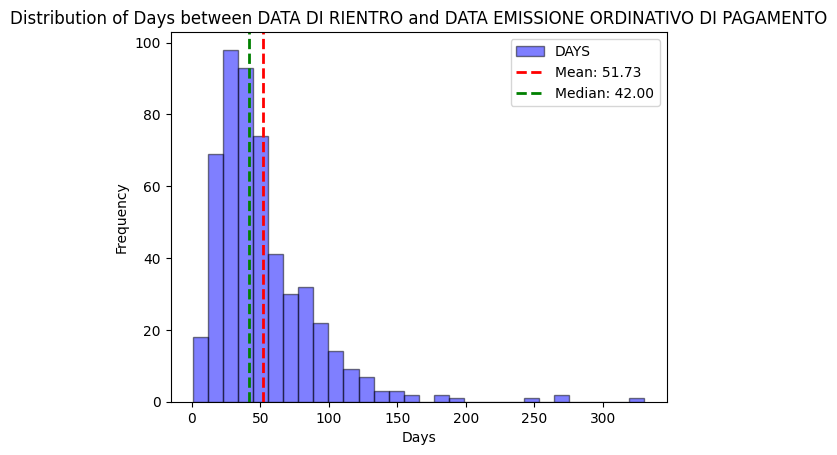

In [23]:
# add a column 'DAYS' with the number of days between 'DATA DI RIENTRO' and 'DATA EMISSIONE ORDINATIVO DI PAGAMENTO'"missioni - 2025.xlsx"

df['DAYS'] = (df['DATA EMISSIONE ORDINATIVO DI PAGAMENTO'] - df['DATA DI RIENTRO']).dt.days

df.head()

# compute the mean and median of the 'DAYS' column
mean_days = df['DAYS'].mean()
median_days = df['DAYS'].median()

print(f"Mean days: {mean_days:.2f}")
print(f"Median days: {median_days:.2f}")

# create a plot of the distribution of the 'DAYS' column using matplotlib. Add vertical lines for the mean and median, and add a legend.

plot = df['DAYS'].plot(kind='hist', bins=30, alpha=0.5, color='blue', edgecolor='black')
plot.axvline(mean_days, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_days:.2f}')
plot.axvline(median_days, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_days:.2f}')
plot.set_xlabel('Days') 
plot.set_ylabel('Frequency')
plot.legend()       
plot.set_title('Distribution of Days between DATA DI RIENTRO and DATA EMISSIONE ORDINATIVO DI PAGAMENTO')



In [11]:
import numpy as np

sigmas_0 = []
sigmas_1 = []

population = np.random.normal(94, 10, 1000000) 

for i in range(1000):
    sample = np.random.choice(population, size=100, replace=False)
    sigma_x_0 = np.std(sample, ddof=0)
    sigma_x_1 = np.std(sample, ddof=1)
    sigmas_0.append(sigma_x_0)
    sigmas_1.append(sigma_x_1)

print(f"Mean of sample std devs (ddof=0): {np.mean(sigmas_0):.6f}")
print(f"Mean of sample std devs (ddof=1): {np.mean(sigmas_1):.6f}")

Mean of sample std devs (ddof=0): 9.916820
Mean of sample std devs (ddof=1): 9.966779
